# Unit 4 — Hidden Markov models

The practice questions of this unit (21CSC305P). Every question below is self-contained: run any cell on its own. All questions use the Seattle daily weather data (`website/data/seattle_weather.csv`); models are trained on 2012–2014 and tested on 2015.

In [1]:
%config InlineBackend.figure_format = "svg"
import sys
sys.path.insert(0, "website")          # weather.py and the data live in website/
from weather import use_style
use_style()

## Practice 1 — Implement HMM to predict the sequential data

Each day is dry, light rain or heavy rain, and a hidden "wet spell" or "dry spell" state drives it. Baum-Welch (EM with the scaled forward and backward passes) learns the model from 2012–2014, Viterbi finds the most likely spells, and the forward pass predicts rain tomorrow for every day of 2015.

transition matrix (rows = from wet / dry):
 [[0.88 0.12]
 [0.12 0.88]]
P(dry, light, heavy) in each state:
 [[0.19 0.44 0.37]
 [0.93 0.07 0.  ]]
average length of a spell (days): wet 8.2 | dry 8.6

rain tomorrow, accuracy on 2015:  HMM 0.687  |  'tomorrow = today' 0.703


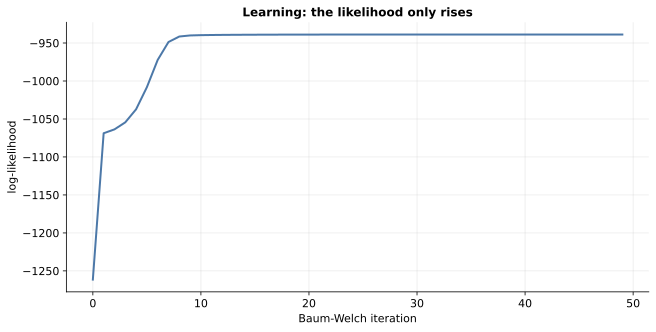

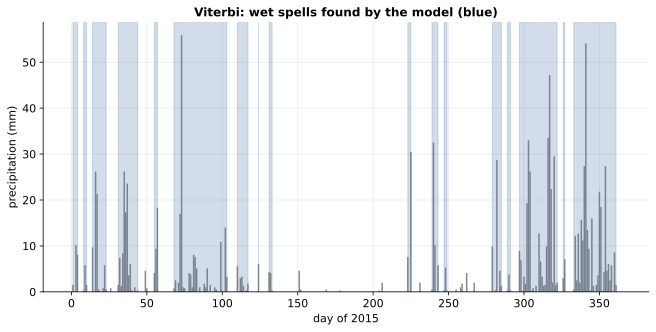

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from weather import load

d = load()
obs = np.digitize(d.precipitation, [0.001, 5.0])                      # 0 = dry, 1 = light rain, 2 = heavy rain
n_train = int((d.date < "2015-01-01").sum())
K = 2                                                                 # two hidden states

def forward(obs, A, B, pi):                                           # scaled forward pass
    alpha, c = np.zeros((len(obs), len(pi))), np.zeros(len(obs))
    for t in range(len(obs)):
        alpha[t] = (pi if t == 0 else alpha[t - 1] @ A) * B[:, obs[t]]
        c[t] = alpha[t].sum(); alpha[t] /= c[t]
    return alpha, c

def baum_welch(obs, seed, iters=50):
    rng = np.random.default_rng(seed)
    A, B, pi = rng.dirichlet(np.ones(K) * 5, K), rng.dirichlet(np.ones(3) * 5, K), np.full(K, 1 / K)
    history = []
    for _ in range(iters):
        alpha, c = forward(obs, A, B, pi); history.append(np.log(c).sum())
        beta = np.ones_like(alpha)                                     # scaled backward pass
        for t in range(len(obs) - 2, -1, -1):
            beta[t] = A @ (B[:, obs[t + 1]] * beta[t + 1]) / c[t + 1]
        gamma = alpha * beta; gamma /= gamma.sum(1, keepdims=True)    # E-step: P(state on day t)
        xi = alpha[:-1, :, None] * A[None] * (B[:, obs[1:]].T * beta[1:])[:, None, :]
        xi /= xi.sum((1, 2), keepdims=True)                           # P(state t, state t+1)
        A = xi.sum(0) / gamma[:-1].sum(0)[:, None]                    # M-step
        B = np.array([[gamma[obs == m, j].sum() for m in range(3)] for j in range(K)]) / gamma.sum(0)[:, None]
        pi = gamma[0]
    return A, B, pi, history

def viterbi(obs, A, B, pi):
    with np.errstate(divide="ignore"):                               # log(0) = -inf is fine here
        lA, lB, lpi = np.log(A), np.log(B), np.log(pi)
    delta, back = lpi + lB[:, obs[0]], []
    for o in obs[1:]:
        s = delta[:, None] + lA; back.append(s.argmax(0)); delta = s.max(0) + lB[:, o]
    path = [int(delta.argmax())]
    for b in back[::-1]: path.append(int(b[path[-1]]))
    return np.array(path[::-1])

A, B, pi, history = max((baum_welch(obs[:n_train], seed) for seed in range(3)), key=lambda r: r[3][-1])
order = np.argsort(B[:, 0]); A, B, pi = A[np.ix_(order, order)], B[order], pi[order]   # state 0 = the wet spell
print("transition matrix (rows = from wet / dry):\n", A.round(2))
print("P(dry, light, heavy) in each state:\n", B.round(2))
print("average length of a spell (days): wet", round(1 / (1 - A[0, 0]), 1), "| dry", round(1 / (1 - A[1, 1]), 1))

alpha, c = forward(obs, A, B, pi)                                      # filter through every day with the learned model
t_days = np.arange(n_train, len(obs) - 1)                              # every 2015 day that has a "tomorrow"
truth = (obs[t_days + 1] > 0).astype(int)
p_rain = (alpha[t_days] @ A @ B)[:, 1:].sum(1)                         # state today -> state tomorrow -> P(rain)
print(f"\nrain tomorrow, accuracy on 2015:  HMM {np.mean((p_rain > .5) == truth):.3f}  |  'tomorrow = today' {np.mean((obs[t_days] > 0) == truth):.3f}")

path = viterbi(obs, A, B, pi)
days = np.arange(n_train, len(obs))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(history); ax.set_xlabel("Baum-Welch iteration"); ax.set_ylabel("log-likelihood"); ax.set_title("Learning: the likelihood only rises")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(range(len(days)), d.precipitation.values[days], color="#888", width=1)
ax.fill_between(range(len(days)), 0, 1, where=path[days] == 0, color="#4c78a8", alpha=.25, transform=ax.get_xaxis_transform())
ax.set_xlabel("day of 2015"); ax.set_ylabel("precipitation (mm)"); ax.set_title("Viterbi: wet spells found by the model (blue)")
plt.show()